# Applying GloVe to analyse Jane Austin's Work

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

# STEP 1: Install required libraries

In [2]:
# !pip install -q gensim scikit-learn matplotlib pandas numpy

# STEP 2: Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

import gensim.downloader as api

print("Downloading GloVe model...")
glove_model = api.load("glove-wiki-gigaword-100")

print("Model loaded successfully.")
print("Vocabulary size:", len(glove_model))

[==================================================] 100.0% 128.1/128.1MB downloaded
Model loaded successfully.
Vocabulary size: 400000


In practice, GloVe models are trained on extremely large corpora and then reused, rather than retrained from scratch for each task.

# STEP 3: Show nearest neighbours for selected probe words

In [4]:
number_of_neighbours = 10

probe_words = ["elizabeth", "darcy", "emma", "love", "marriage", "sense", "family"]

print("STEP 3: Nearest Neighbours")
for word in probe_words:
    if word in glove_model:
        print(f"\nNearest neighbours for '{word}':")
        print(glove_model.most_similar(word, topn=number_of_neighbours))
    else:
        print(f"\n'{word}' not found in vocabulary.")

STEP 3: Nearest Neighbours

Nearest neighbours for 'elizabeth':
[('margaret', 0.8279304504394531), ('mary', 0.8082690834999084), ('catherine', 0.7879205346107483), ('anne', 0.7855517268180847), ('jane', 0.7574265003204346), ('daughter', 0.753700852394104), ('queen', 0.7355712056159973), ('edward', 0.7352322936058044), ('sarah', 0.7134773135185242), ('william', 0.7123982906341553)]

Nearest neighbours for 'darcy':
[('joanna', 0.5408821105957031), ('bennet', 0.5401017069816589), ('sonya', 0.5373843908309937), ('kellie', 0.5255778431892395), ('georgina', 0.5253818035125732), ('eamonn', 0.5251210331916809), ('fitzwilliam', 0.5222243666648865), ('pattie', 0.5207604765892029), ('bothwell', 0.5186071991920471), ('quinn', 0.5047281384468079)]

Nearest neighbours for 'emma':
[('emily', 0.7630564570426941), ('catherine', 0.7424191236495972), ('helen', 0.7261478900909424), ('kate', 0.7191192507743835), ('lucy', 0.7162103652954102), ('alice', 0.7136399149894714), ('sarah', 0.704693078994751), ('ja

# STEP 4: Select words for t-SNE visualisation

We select the most frequent words from the corpus in dictionary order.

To keep the plot readable, we restrict to a subset.



In [5]:
number_of_top_words = 30
max_plot_words = 250

# Gensim stores vocabulary in key_to_index
all_words = list(glove_model.key_to_index.keys())

# We approximate "importance" using word frequency ranking already built into GloVe
sorted_words = all_words  # already frequency-sorted in Gensim

# Filter meaningful words
plot_words = []
for word in sorted_words:
    if word.isalpha() and len(word) > 2:
        plot_words.append(word)
    if len(plot_words) == max_plot_words:
        break

print("STEP 4: Words selected for t-SNE")
print("Number of words selected =", len(plot_words))
print(f"First {number_of_top_words} selected words:")
print(plot_words[:number_of_top_words])

STEP 4: Words selected for t-SNE
Number of words selected = 250
First 30 selected words:
['the', 'and', 'for', 'that', 'was', 'said', 'with', 'from', 'his', 'has', 'are', 'have', 'but', 'were', 'not', 'this', 'who', 'they', 'had', 'which', 'will', 'their', 'its', 'one', 'after', 'new', 'been', 'also', 'would', 'two']


# STEP 5: Extract vectors for t-SNE

In [6]:
plot_vectors = np.array([glove_model[word] for word in plot_words])

print("STEP 5: Vector Matrix for t-SNE")
print("Shape =", plot_vectors.shape)

STEP 5: Vector Matrix for t-SNE
Shape = (250, 100)


# STEP 6: Apply t-SNE

In [7]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

vectors_2d = tsne.fit_transform(plot_vectors)

tsne_df = pd.DataFrame({
    "word": plot_words,
    "x": vectors_2d[:, 0],
    "y": vectors_2d[:, 1]
})

print("STEP 6: t-SNE completed")
print(tsne_df.head())

STEP 6: t-SNE completed
   word         x         y
0   the -1.283895 -6.040973
1   and -3.039300 -3.269737
2   for -2.946064 -4.420925
3  that -5.853223  2.875380
4   was  1.561313  3.695988


# STEP 7: Plot the t-SNE embedding space

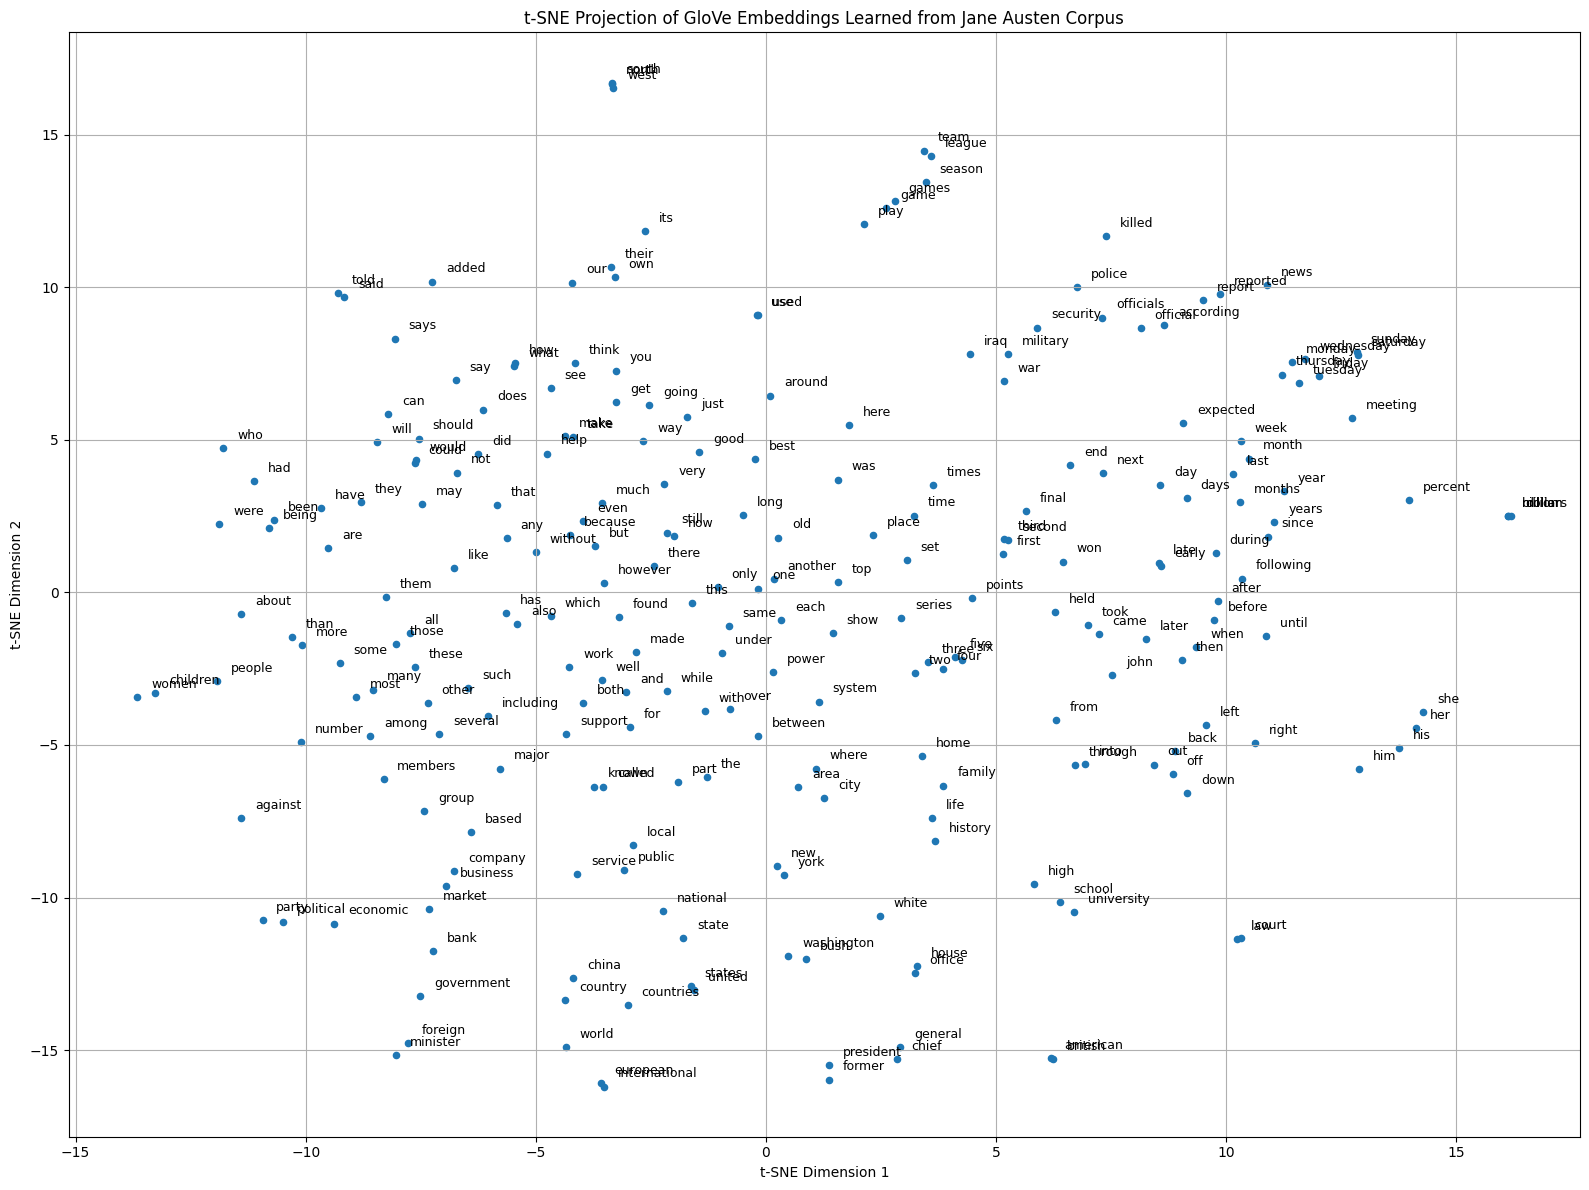

In [8]:
plt.figure(figsize=(16, 12))
plt.scatter(tsne_df["x"], tsne_df["y"], s=20)

for _, row in tsne_df.iterrows():
    plt.text(row["x"] + 0.3, row["y"] + 0.3, row["word"], fontsize=9)

plt.title("t-SNE Projection of GloVe Embeddings Learned from Jane Austen Corpus")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: Focused t-SNE on important Austen words

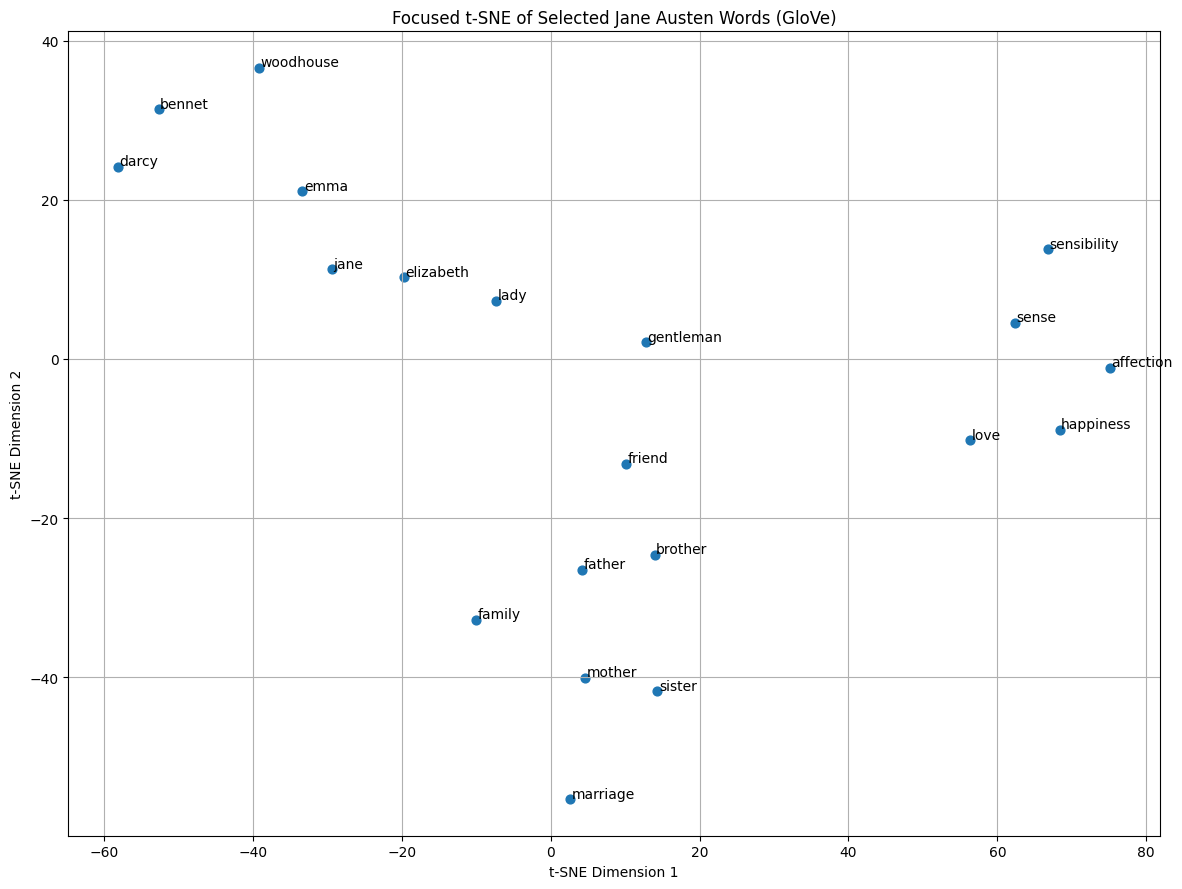

In [9]:
focus_words = [
    "elizabeth", "darcy", "jane", "bennet", "emma", "woodhouse",
    "sense", "sensibility", "love", "marriage", "family",
    "friend", "mother", "father", "sister", "brother",
    "lady", "gentleman", "happiness", "affection"
]

# Keep only words present in the GloVe model
focus_words = [w for w in focus_words if w in glove_model.key_to_index]

# Extract vectors directly
focus_vectors = np.array([glove_model[word] for word in focus_words])

tsne_focus = TSNE(
    n_components=2,
    perplexity=min(5, len(focus_words) - 1),
    learning_rate="auto",
    init="pca",
    random_state=42
)

focus_2d = tsne_focus.fit_transform(focus_vectors)

focus_df = pd.DataFrame({
    "word": focus_words,
    "x": focus_2d[:, 0],
    "y": focus_2d[:, 1]
})

plt.figure(figsize=(12, 9))
plt.scatter(focus_df["x"], focus_df["y"], s=40)

for _, row in focus_df.iterrows():
    plt.text(row["x"] + 0.2, row["y"] + 0.2, row["word"], fontsize=10)

plt.title("Focused t-SNE of Selected Jane Austen Words (GloVe)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()